# Learning the noise from data

A filter is only as good as its `Q` and `R`. They are rarely known: `R` comes from a data
sheet that may not match the installation, and `Q` is a modeling choice. `fit_noise` estimates
them by maximum likelihood from the measurements alone.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from kalman_py import KalmanFilter
from kalman_py.diagnostics import chi2_bounds
from kalman_py.learning import fit_noise

rng = np.random.default_rng(3)

## Data with unknown noise

A 2-D constant-velocity target, as in the tracking tutorial. The noise below generates the
data, but the filter will not be told it.

In [2]:
dt = 0.5
F = np.eye(4)
F[0, 2] = F[1, 3] = dt
H = np.array([[1.0, 0, 0, 0], [0, 1.0, 0, 0]])
block = 0.3 * np.array([[dt**3 / 3, dt**2 / 2], [dt**2 / 2, dt]])
Q_true = np.zeros((4, 4))
Q_true[np.ix_([0, 2], [0, 2])] = block
Q_true[np.ix_([1, 3], [1, 3])] = block
R_true = np.diag([2.0, 0.5])
x0, P0 = np.zeros(4), np.eye(4)

x = rng.multivariate_normal(x0, P0)
truth, zs = np.empty((1000, 4)), np.empty((1000, 2))
for k in range(1000):
    x = F @ x + rng.multivariate_normal(np.zeros(4), Q_true)
    truth[k] = x
    zs[k] = H @ x + rng.multivariate_normal(np.zeros(2), R_true)

## Fit Q and R

Two methods, both starting from identity matrices. EM needs only NumPy and improves the
likelihood at every iteration, but slowly. The gradient method differentiates the exact
likelihood through the JAX filter and uses BFGS.

In [3]:
import jax

jax.config.update("jax_enable_x64", True)

em = fit_noise(F, H, zs, x0, P0, method="em", max_iter=300)
grad = fit_noise(F, H, zs, x0, P0, method="gradient")
print(
    f"EM:       log-likelihood {em.log_likelihood:9.2f}, {em.n_iter} iterations"
)
print(
    f"gradient: log-likelihood {grad.log_likelihood:9.2f}, {grad.converged=}"
)

EM:       log-likelihood  -3417.46, 300 iterations
gradient: log-likelihood  -3416.90, grad.converged=True


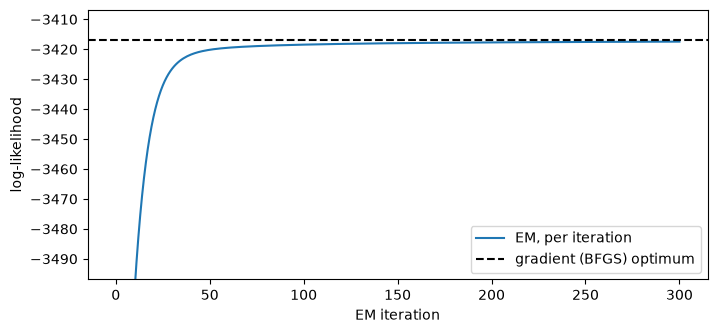

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(em.history, label="EM, per iteration")
ax.axhline(
    grad.log_likelihood,
    color="black",
    linestyle="--",
    label="gradient (BFGS) optimum",
)
ax.set_xlabel("EM iteration")
ax.set_ylabel("log-likelihood")
ax.set_ylim(grad.log_likelihood - 80, grad.log_likelihood + 10)
ax.legend()
plt.show()

EM climbs quickly at first and then crawls toward the optimum the gradient method reaches
directly. The fitted measurement noise is close to the truth:

In [5]:
print("fitted R (gradient):\n", grad.R.round(3))
print("true R:\n", R_true)

fitted R (gradient):
 [[1.874 0.029]
 [0.029 0.454]]
true R:
 [[2.  0. ]
 [0.  0.5]]


The fitted `Q` can look quite different from the true one even though its likelihood is
higher: with position-only measurements, many process-noise matrices explain the data almost
equally well. What matters is how the filter performs with it.

## Does it help?

Compare filters using the true noise, a poor guess (identity matrices), and the fitted noise,
on fresh data from the same system. Calibration is checked with the NIS, which needs no ground
truth, so the same check works on real data. Innovations of a correct filter are white, so
over 2,000 steps their average NIS has a narrow 95% interval around 2.

In [6]:
x = rng.multivariate_normal(x0, P0)
test_truth, test_zs = np.empty((2000, 4)), np.empty((2000, 2))
for k in range(2000):
    x = F @ x + rng.multivariate_normal(np.zeros(4), Q_true)
    test_truth[k] = x
    test_zs[k] = H @ x + rng.multivariate_normal(np.zeros(2), R_true)

for name, Q_, R_ in [
    ("true noise", Q_true, R_true),
    ("guess (identity)", np.eye(4), np.eye(2)),
    ("fitted (gradient)", grad.Q, grad.R),
]:
    result = KalmanFilter(F, H, Q_, R_, x0, P0).filter(test_zs)
    rmse = np.sqrt(
        np.mean(np.sum((result.means[:, :2] - test_truth[:, :2]) ** 2, axis=1))
    )
    nis = result.nis.mean()
    print(f"{name:18s} position RMSE {rmse:5.3f} m, average NIS {nis:5.2f}")

lower, upper = chi2_bounds(dof=2, n_runs=len(test_zs))
print(
    f"95% interval for a correct filter's average NIS: [{lower:.2f}, {upper:.2f}]"
)

true noise         position RMSE 1.022 m, average NIS  2.01
guess (identity)   position RMSE 1.257 m, average NIS  1.34
fitted (gradient)  position RMSE 1.030 m, average NIS  2.13
95% interval for a correct filter's average NIS: [1.91, 2.09]


With the fitted noise the filter is as accurate as with the true noise, and its average NIS
is close to the expected 2, just above the interval: it is slightly overconfident, as expected
from noise estimated on a different, finite data set. The identity guess is clearly less
accurate, and its NIS far below 2 shows it overestimates its uncertainty.

Use `estimate=("R",)` to fit only one of them when the other is known, and `Q0`, `R0` to start
from a better guess.